In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt



========== ORIGINAL DATA ==========
         Date      Customer       Product     Category    Sales  Revenue
0  2026-01-03  Aarav Sharma        Laptop  Electronics  55000.0  55000.0
1  2026-01-05   Priya Verma    Smartphone  Electronics  32000.0  32000.0
2  2026-01-08   Rohan Mehta  Office Chair    Furniture   8500.0   8500.0
3  2026-01-12    Neha Gupta    Headphones  Electronics   4500.0   4500.0
4  2026-01-15  Aarav Sharma       Monitor  Electronics  18000.0  18000.0

Dataset Shape: (45, 6)

Columns: ['Date', 'Customer', 'Product', 'Category', 'Sales', 'Revenue']

Duplicate rows: 1

Missing values before cleaning:
Date        0
Customer    0
Product     0
Category    0
Sales       1
Revenue     1
dtype: int64

Missing values after cleaning:
Date        0
Customer    0
Product     0
Category    0
Sales       0
Revenue     0
dtype: int64

Dataset after cleaning:
         Date      Customer       Product     Category    Sales  Revenue
0  2026-01-03  Aarav Sharma        Laptop  Electron

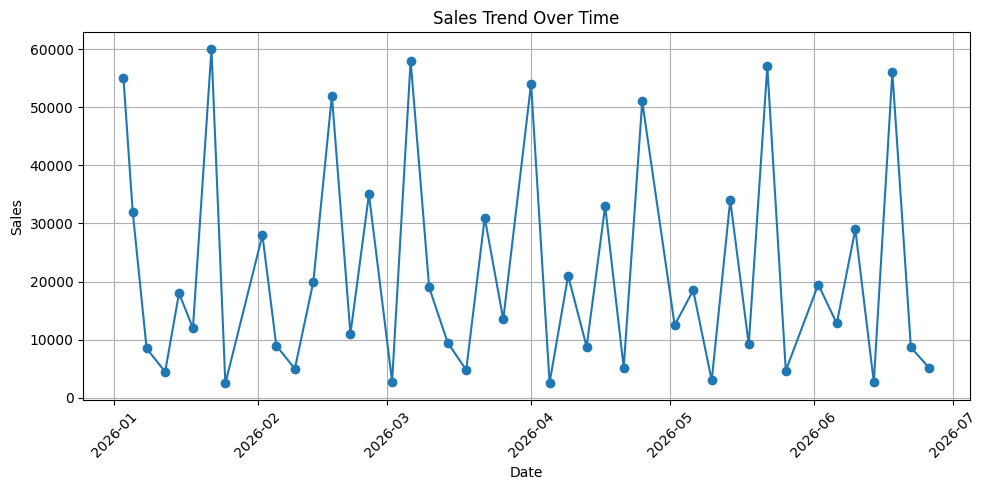


========== TOP PRODUCTS ==========
Product
Laptop          443000.0
Smartphone      222000.0
Monitor         116000.0
Desk             61800.0
Office Chair     53700.0
Name: Sales, dtype: float64


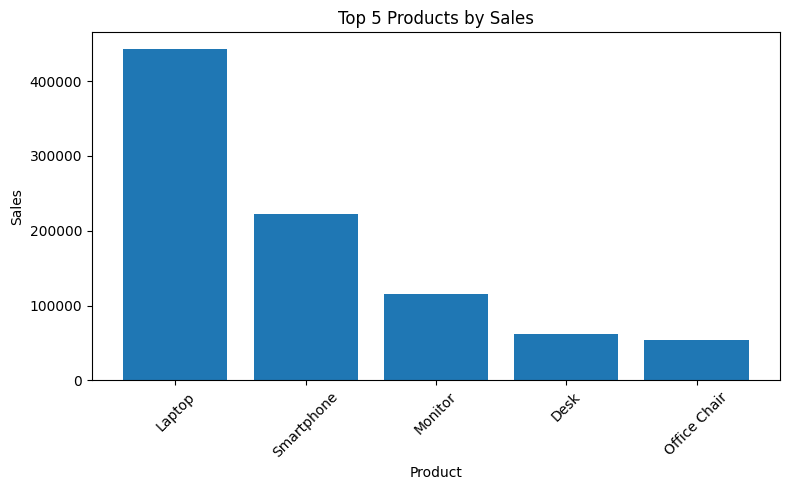


========== CATEGORY DISTRIBUTION ==========
Category
Accessories     13600.0
Electronics    810300.0
Furniture      115500.0
Name: Sales, dtype: float64


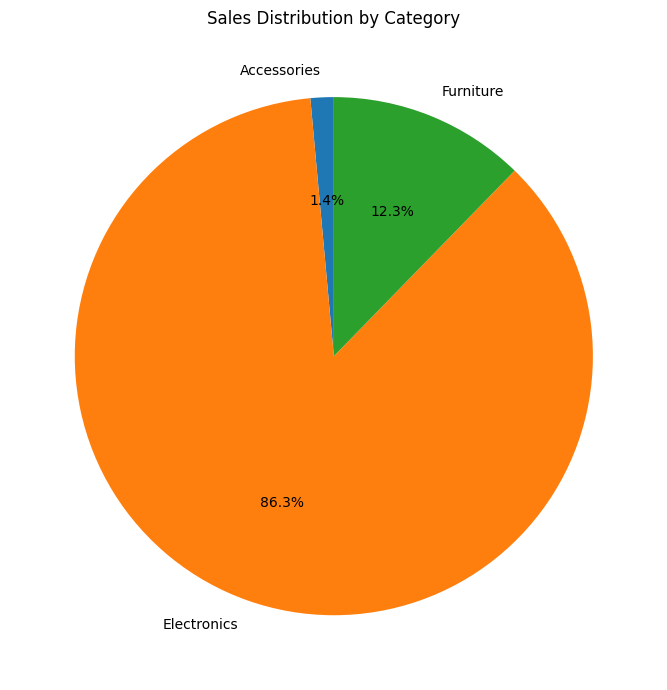



========== BUSINESS INSIGHTS ==========
1. Total sales generated: 939400.0
2. Rohan Mehta is the highest-value customer with sales of 224200.00.
3. Laptop is the best-performing product based on total sales.
4. Electronics is the category contributing the highest sales.
5. The highest sales were recorded on 2026-01-22.

       DASHBOARD ANALYSIS COMPLETE


In [ ]:
df = pd.read_csv("sales.csv")

print("\n========== ORIGINAL DATA ==========")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Remove duplicate rows
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)

df = df.drop_duplicates()

# Display missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Remove rows having missing values
df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDataset after cleaning:")
print(df.head())


# Convert Date column if available
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])

# Convert Sales/Revenue to numeric
if "Sales" in df.columns:
    df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

if "Revenue" in df.columns:
    df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

# Remove rows where numeric conversion failed
df = df.dropna()

if "Sales" in df.columns:
    total_sales = df["Sales"].sum()
    print("\n💰 Total Sales:", total_sales)

elif "Revenue" in df.columns:
    total_sales = df["Revenue"].sum()
    print("\n💰 Total Sales:", total_sales)

else:
    print("\nSales/Revenue column not found.")


if "Revenue" in df.columns:
    average_revenue = df["Revenue"].mean()
    print("📊 Average Revenue:", round(average_revenue, 2))

elif "Sales" in df.columns:
    average_revenue = df["Sales"].mean()
    print("📊 Average Revenue:", round(average_revenue, 2))


if "Customer" in df.columns:

    sales_column = "Sales" if "Sales" in df.columns else "Revenue"

    top_customers = (
        df.groupby("Customer")[sales_column]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    print("\n========== TOP 5 CUSTOMERS ==========")
    print(top_customers)

else:
    print("\nCustomer column not found.")


if "Date" in df.columns:

    sales_column = "Sales" if "Sales" in df.columns else "Revenue"

    sales_trend = df.groupby("Date")[sales_column].sum()

    plt.figure(figsize=(10, 5))

    plt.plot(
        sales_trend.index,
        sales_trend.values,
        marker="o"
    )

    plt.title("Sales Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()

    plt.show()

else:
    print("\nDate column not found for Sales Trend.")


if "Product" in df.columns:

    sales_column = "Sales" if "Sales" in df.columns else "Revenue"

    top_products = (
        df.groupby("Product")[sales_column]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )

    print("\n========== TOP PRODUCTS ==========")
    print(top_products)

    plt.figure(figsize=(8, 5))

    plt.bar(
        top_products.index,
        top_products.values
    )

    plt.title("Top 5 Products by Sales")
    plt.xlabel("Product")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

else:
    print("\nProduct column not found.")

if "Category" in df.columns:

    sales_column = "Sales" if "Sales" in df.columns else "Revenue"

    category_sales = df.groupby("Category")[sales_column].sum()

    print("\n========== CATEGORY DISTRIBUTION ==========")
    print(category_sales)

    plt.figure(figsize=(7, 7))

    plt.pie(
        category_sales.values,
        labels=category_sales.index,
        autopct="%1.1f%%",
        startangle=90
    )

    plt.title("Sales Distribution by Category")
    plt.tight_layout()

    plt.show()

else:
    print("\nCategory column not found.")

print("\n\n========== BUSINESS INSIGHTS ==========")

# Insight 1
if "Sales" in df.columns:
    print("1. Total sales generated:",
          round(df["Sales"].sum(), 2))
elif "Revenue" in df.columns:
    print("1. Total revenue generated:",
          round(df["Revenue"].sum(), 2))


# Insight 2
if "Customer" in df.columns:
    top_customer = (
        df.groupby("Customer")[sales_column]
        .sum()
        .idxmax()
    )

    top_customer_sales = (
        df.groupby("Customer")[sales_column]
        .sum()
        .max()
    )

    print(
        f"2. {top_customer} is the highest-value customer "
        f"with sales of {top_customer_sales:.2f}."
    )


# Insight 3
if "Product" in df.columns:
    top_product = (
        df.groupby("Product")[sales_column]
        .sum()
        .idxmax()
    )

    print(
        f"3. {top_product} is the best-performing product "
        "based on total sales."
    )


# Insight 4
if "Category" in df.columns:
    top_category = (
        df.groupby("Category")[sales_column]
        .sum()
        .idxmax()
    )

    print(
        f"4. {top_category} is the category contributing "
        "the highest sales."
    )


# Insight 5
if "Date" in df.columns:
    daily_sales = df.groupby("Date")[sales_column].sum()

    highest_sales_date = daily_sales.idxmax()

    print(
        f"5. The highest sales were recorded on "
        f"{highest_sales_date.date()}."
    )


print("\n========================================")
print("       DASHBOARD ANALYSIS COMPLETE")
print("========================================")